In [3]:
%reload_ext autoreload
%autoreload 2

In [4]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [5]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Plotting Functions

## One Section

In [6]:
def one_section_train_val_test_splits(
        data_batch,
        title = 'Spatial Distribution of Train/Validation/Test Splits',
    ):
    # Extract the data attributes
    print("Extracting data attributes...")
    print(f"Data batch keys: {list(data_batch.keys())}")
    print(f"Number of nodes: {data_batch.x.shape[0]}")
    print(f"Number of features: {data_batch.x.shape[1]}")
    print(f"Number of edges: {data_batch.edge_index.shape[1]}")

    # Get coordinates and masks
    xy_coords = data_batch.xy_coordinates.numpy()
    train_mask = data_batch.train_mask.numpy()
    val_mask = data_batch.val_mask.numpy()
    test_mask = data_batch.test_mask.numpy()

    print(f"Train nodes: {train_mask.sum()}")
    print(f"Val nodes: {val_mask.sum()}")
    print(f"Test nodes: {test_mask.sum()}")
    print(f"Total nodes: {len(train_mask)}")

    # Create the visualization
    plt.figure(figsize=(12, 8))

    # Plot points colored by their split
    train_coords = xy_coords[train_mask]
    val_coords = xy_coords[val_mask]
    test_coords = xy_coords[test_mask]

    plt.scatter(train_coords[:, 0], train_coords[:, 1], 
            c='lightgrey', alpha=0.6, s=1, label=f'Train ({len(train_coords)})')
    plt.scatter(val_coords[:, 0], val_coords[:, 1], 
            c='blue', alpha=0.8, s=1, label=f'Validation ({len(val_coords)})')
    plt.scatter(test_coords[:, 0], test_coords[:, 1], 
            c='red', alpha=0.8, s=1, label=f'Test ({len(test_coords)})')

    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')

    # Add some statistics
    total_nodes = len(train_mask)
    train_pct = (train_mask.sum() / total_nodes) * 100
    val_pct = (val_mask.sum() / total_nodes) * 100
    test_pct = (test_mask.sum() / total_nodes) * 100

    plt.figtext(0.02, 0.02, f'Split ratios - Train: {train_pct:.1f}% | Val: {val_pct:.1f}% | Test: {test_pct:.1f}%', 
                fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.tight_layout()
    plt.show()

    # Optional: Create a second plot showing the spatial density of each split
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    splits = [('Train', train_mask, 'lightgrey'), ('Validation', val_mask, 'blue'), ('Test', test_mask, 'red')]

    for i, (split_name, mask, color) in enumerate(splits):
        coords = xy_coords[mask]
        axes[i].scatter(coords[:, 0], coords[:, 1], c=color, alpha=0.6, s=1)
        axes[i].set_title(f'{split_name} Set ({len(coords)} nodes)')
        axes[i].set_xlabel('X coordinate')
        axes[i].set_ylabel('Y coordinate')
        axes[i].grid(True, alpha=0.3)
        axes[i].axis('equal')

    plt.tight_layout()
    plt.show()

## Multiple Sections

In [17]:
import math
import matplotlib.pyplot as plt
import torch

def multiple_sections_train_val_test_splits(
        data_batch,
        height=5,
        width=6,
        title='Spatial Distribution of Train/Validation/Test Splits',
        xlim=None,
        ylim=None,
        fname=None
    ):
    colors = {'train': 'lightgrey', 'val': 'blue', 'test': 'red'}

    n_graphs = len(data_batch.adata_batch_id)
    n_rows = math.ceil(n_graphs/5)
    n_cols = min(n_graphs, 5)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(n_cols*width, n_rows*height),
        squeeze=False
    )

    use_ptr = hasattr(data_batch, 'ptr') and data_batch.ptr is not None

    # --- compute global coordinate ranges ---
    coords_all = data_batch.xy_coordinates.cpu()
    x_min, x_max = coords_all[:, 0].min().item(), coords_all[:, 0].max().item()
    y_min, y_max = coords_all[:, 1].min().item(), coords_all[:, 1].max().item()

    for i in range(n_graphs):
        # row, col = divmod(i, n_cols)
        # ax = axes[row, col]
        ax = axes.flatten()[i]

        if use_ptr:
            start = int(data_batch.ptr[i])
            end = int(data_batch.ptr[i+1])
            idx = torch.arange(start, end, device=data_batch.xy_coordinates.device)
        else:
            idx = (data_batch.batch == i).nonzero(as_tuple=True)[0]

        coords = data_batch.xy_coordinates[idx].cpu()
        train = data_batch.train_mask[idx].cpu()
        val = data_batch.val_mask[idx].cpu()
        test = data_batch.test_mask[idx].cpu()

        if train.any():
            ax.scatter(coords[train, 0], coords[train, 1], s=5, c=colors['train'], label='train')
        if val.any():
            ax.scatter(coords[val, 0], coords[val, 1], s=5, c=colors['val'], label='val')
        if test.any():
            ax.scatter(coords[test, 0], coords[test, 1], s=5, c=colors['test'], label='test')

        ax.set_title(f'Batch {data_batch.adata_batch_id[i]}')
        ax.set_aspect('equal')
        if xlim != -1:
            if xlim is None:
                xlim = (x_min, x_max)
            ax.set_xlim(xlim)
        if ylim != -1:
            if ylim is None:
                ylim = (y_min, y_max)
            ax.set_ylim(ylim)

        ax.set_xlabel("X coordinate")
        ax.set_ylabel("Y coordinate")

    # remove empty subplots if any
    for j in range(n_graphs, n_rows*n_cols):
        row, col = divmod(j, n_cols)
        fig.delaxes(axes[row, col])

    # Legend in the last axis used
    axes[(n_graphs-1)//n_cols, (n_graphs-1)%n_cols].legend(loc='lower right', frameon=False)

    plt.suptitle(title)
    plt.tight_layout()
    
    if fname is not None:
        fname = f"/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/datasets/{fname}"
        plt.savefig(fname)
    else:
        plt.show()

In [113]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np
import torch

def _get_slice_indices(data_batch, i, use_ptr):
    if use_ptr:
        start = int(data_batch.ptr[i]); end = int(data_batch.ptr[i+1])
        return torch.arange(start, end, device=data_batch.xy_coordinates.device)
    return (data_batch.batch == i).nonzero(as_tuple=True)[0]

def stack_sections_3d(
    data_batch,
    spacing_microns=60.0,
    title="3D stack of sections (aligned bbox, pulled-out highlights)",
    s=1,
    alpha=0.7,
    highlight_sections_1based=(2,4,6,8),   # human indexing
    offset_factor=5,                        # fraction of global width to shift
    highlight_bbox_lw=4.0,
    normal_bbox_lw=1.0,
    normal_bbox_alpha=0.1                   # faded grey alpha for non-highlight bboxes
):
    n_graphs = len(data_batch.adata_batch_id)
    use_ptr = hasattr(data_batch, 'ptr') and data_batch.ptr is not None

    # global extents (shared bounding box)
    coords_all = data_batch.xy_coordinates.cpu().numpy()
    gxmin, gxmax = coords_all[:, 0].min(), coords_all[:, 0].max()
    gymin, gymax = coords_all[:, 1].min(), coords_all[:, 1].max()
    gwidth = gxmax - gxmin
    dx = offset_factor * gwidth * 100

    highlights = set([h-1 for h in highlight_sections_1based if 1 <= h <= n_graphs])

    base_cmap = plt.cm.Oranges
    norm = plt.Normalize(vmin=0, vmax=n_graphs - 1)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')

        # --- Background tweaks ---
    ax.set_facecolor("white")  # base background
    ax.grid(False)             # remove grid
    # make 3D panes white too
    ax.xaxis.pane.set_facecolor((1, 1, 1, 1))
    ax.yaxis.pane.set_facecolor((1, 1, 1, 1))
    ax.zaxis.pane.set_facecolor((1, 1, 1, 1))
    # remove pane borders
    ax.xaxis.pane.set_edgecolor("w")
    ax.yaxis.pane.set_edgecolor("w")
    ax.zaxis.pane.set_edgecolor("w")

    for i in range(n_graphs):
        idx = _get_slice_indices(data_batch, i, use_ptr)
        coords = data_batch.xy_coordinates[idx].cpu().numpy()
        z = np.full((coords.shape[0],), i * spacing_microns, dtype=float)

        is_highlight = i in highlights
        x_shift = dx if is_highlight else 0.0

        coords_shifted = coords.copy()
        coords_shifted[:, 0] += x_shift
        color = base_cmap(norm(i))

        ax.scatter(coords_shifted[:, 0], coords_shifted[:, 1], z, s=s, alpha=alpha,
                   c=[color], depthshade=False)

        # shared bbox at this Z, shifted if highlighted
        bbox_x = np.array([gxmin, gxmax, gxmax, gxmin, gxmin]) + x_shift
        bbox_y = np.array([gymin, gymin, gymax, gymax, gymin])
        bbox_z = np.full(5, i * spacing_microns, dtype=float)

        if is_highlight:
            ax.plot(bbox_x, bbox_y, bbox_z,
                    color='black',
                    linewidth=highlight_bbox_lw,
                    alpha=1)
        else:
            ax.plot(bbox_x, bbox_y, bbox_z,
                    color='black',
                    linewidth=normal_bbox_lw,
                    alpha=normal_bbox_alpha)

    # expand x-limits to include shifted bboxes
    ax.set_xlim(gxmin, gxmax + dx + 0.02 * gwidth)
    ax.set_ylim(gymin, gymax)
    # ax.set_zlim(-spacing_microns * 0.5, spacing_microns * (n_graphs - 0.5))

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap=base_cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.08, shrink=0.8)
    cbar.set_label('Section ID (bottom → top)')

    plt.tight_layout()
    plt.show()
    save_fname = "/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/fig/3D_skin_tissue.pdf"
    plt.savefig(save_fname)

# Dataset: Xenium Skin (Human) | Section: Batch 11

## Random Split (80-10-10)

In [ ]:
xhs1000_39b_1p_batch11_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-batch11_random-split_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_batch11_rdn_file, 'r') as f:
    xhs1000_39b_1p_batch11_rdn_cfg = yaml.safe_load(f)

NameError: name 'Path' is not defined

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(xhs1000_39b_1p_batch11_rdn_cfg)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_batch11_rdn_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_batch11_rdn_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[17832, 1000], y=[17832, 41], edge_index=[2, 183562], encoder_conditions=[17832, 48], encoder_condition_dim=48, spatial_prior_features=[17832, 8], spatial_prior_feature_dim=8, attr_decoder_conditions=[17832, 48], attr_decoder_condition_dim=48, adj_decoder_condition_dim=0, num_features=1000, num_classes=41, num_nodes=17832, num_edges=[1], train_mask=[17832], val_mask=[17832], test_mask=[17832], batch=[17832], ptr=[2], adata_batch_ids=[17832])
Batch ID(s): [11]
Data Batch: DataBatch(y_cell_types=[17832, 41], y_niche_types=[17832, 15], xy_coordinates=[17832, 2], cell_id=[1

Extracting data attributes...
Data batch keys: ['test_mask', 'num_features', 'attr_decoder_conditions', 'num_nodes', 'attr_decoder_condition_dim', 'adata_batch_id', 'y', 'encoder_conditions', 'cell_id', 'adata_batch_ids', 'x', 'num_edges', 'val_mask', 'spatial_prior_feature_dim', 'encoder_condition_dim', 'y_niche_types', 'edge_index', 'dataset_id', 'train_mask', 'species', 'ptr', 'xy_coordinates', 'adj_decoder_condition_dim', 'y_cell_types', 'spatial_prior_features', 'batch', 'tissue', 'num_classes']
Number of nodes: 17832
Number of features: 1000
Number of edges: 183562
Train nodes: 14266
Val nodes: 1783
Test nodes: 1783
Total nodes: 17832


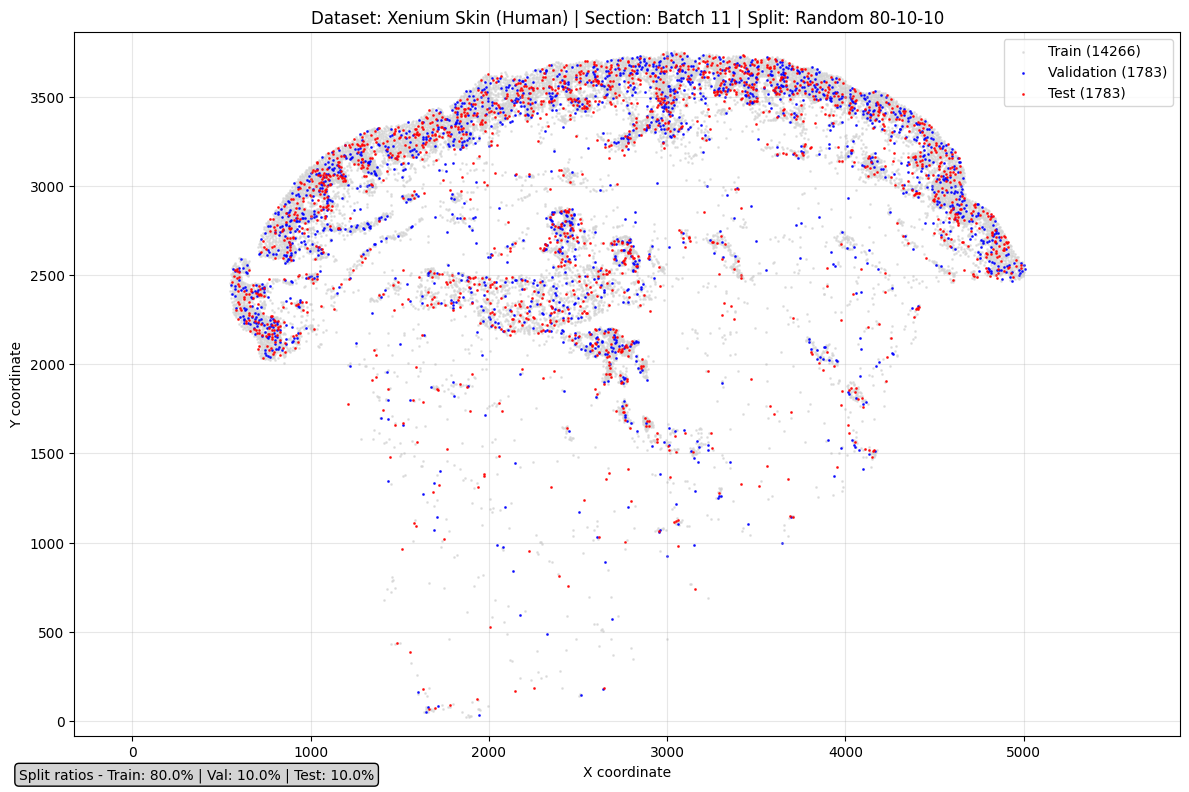

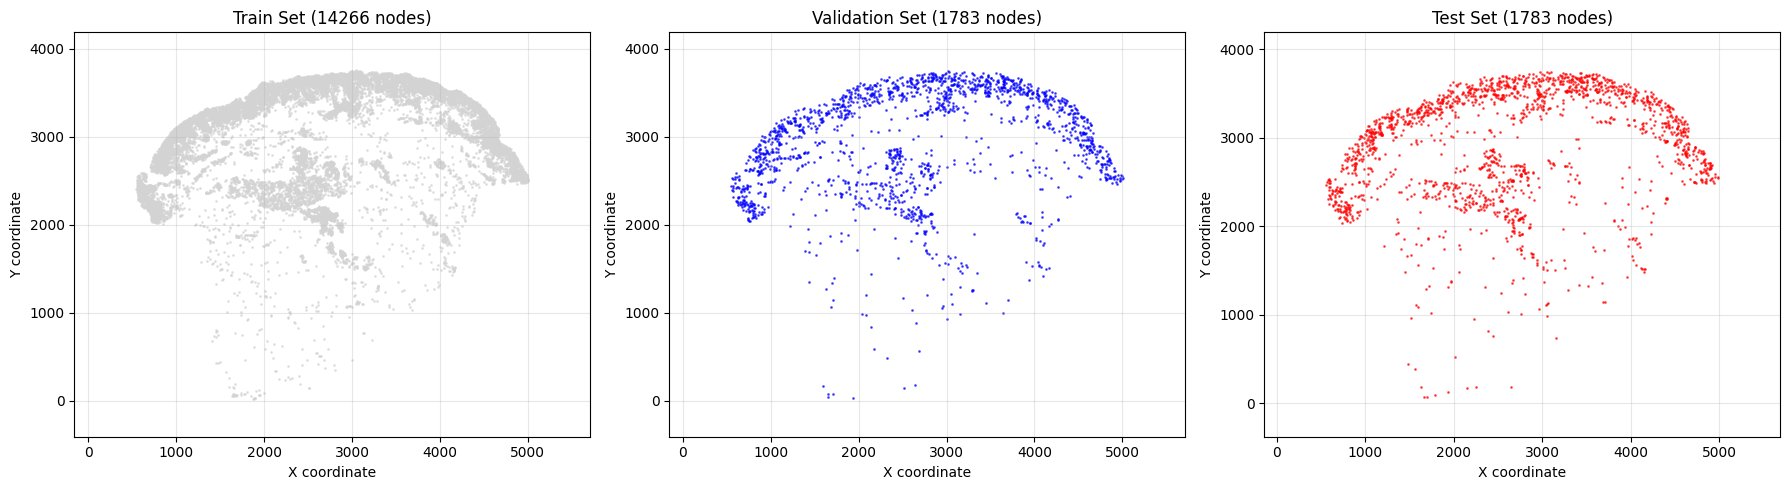

In [ ]:
one_section_train_val_test_splits(
    data_batch=xhs1000_39b_1p_batch11_rdn_data_batch,
    title='Dataset: Xenium Skin (Human) | Section: Batch 11 | Split: Random 80-10-10'
)

# Dataset: Xenium Skin (Human) | All Sections

In [ ]:
xhs1000_39b_1p_all_sections_all_cells_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-all-sections_all-cells_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_all_sections_all_cells_file, 'r') as f:
    xhs1000_39b_1p_all_sections_all_cells_cfg = yaml.safe_load(f)

In [145]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1000_39b_1p_all_sections_all_cells_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_all_sections_all_cells_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_all_sections_all_cells_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setti

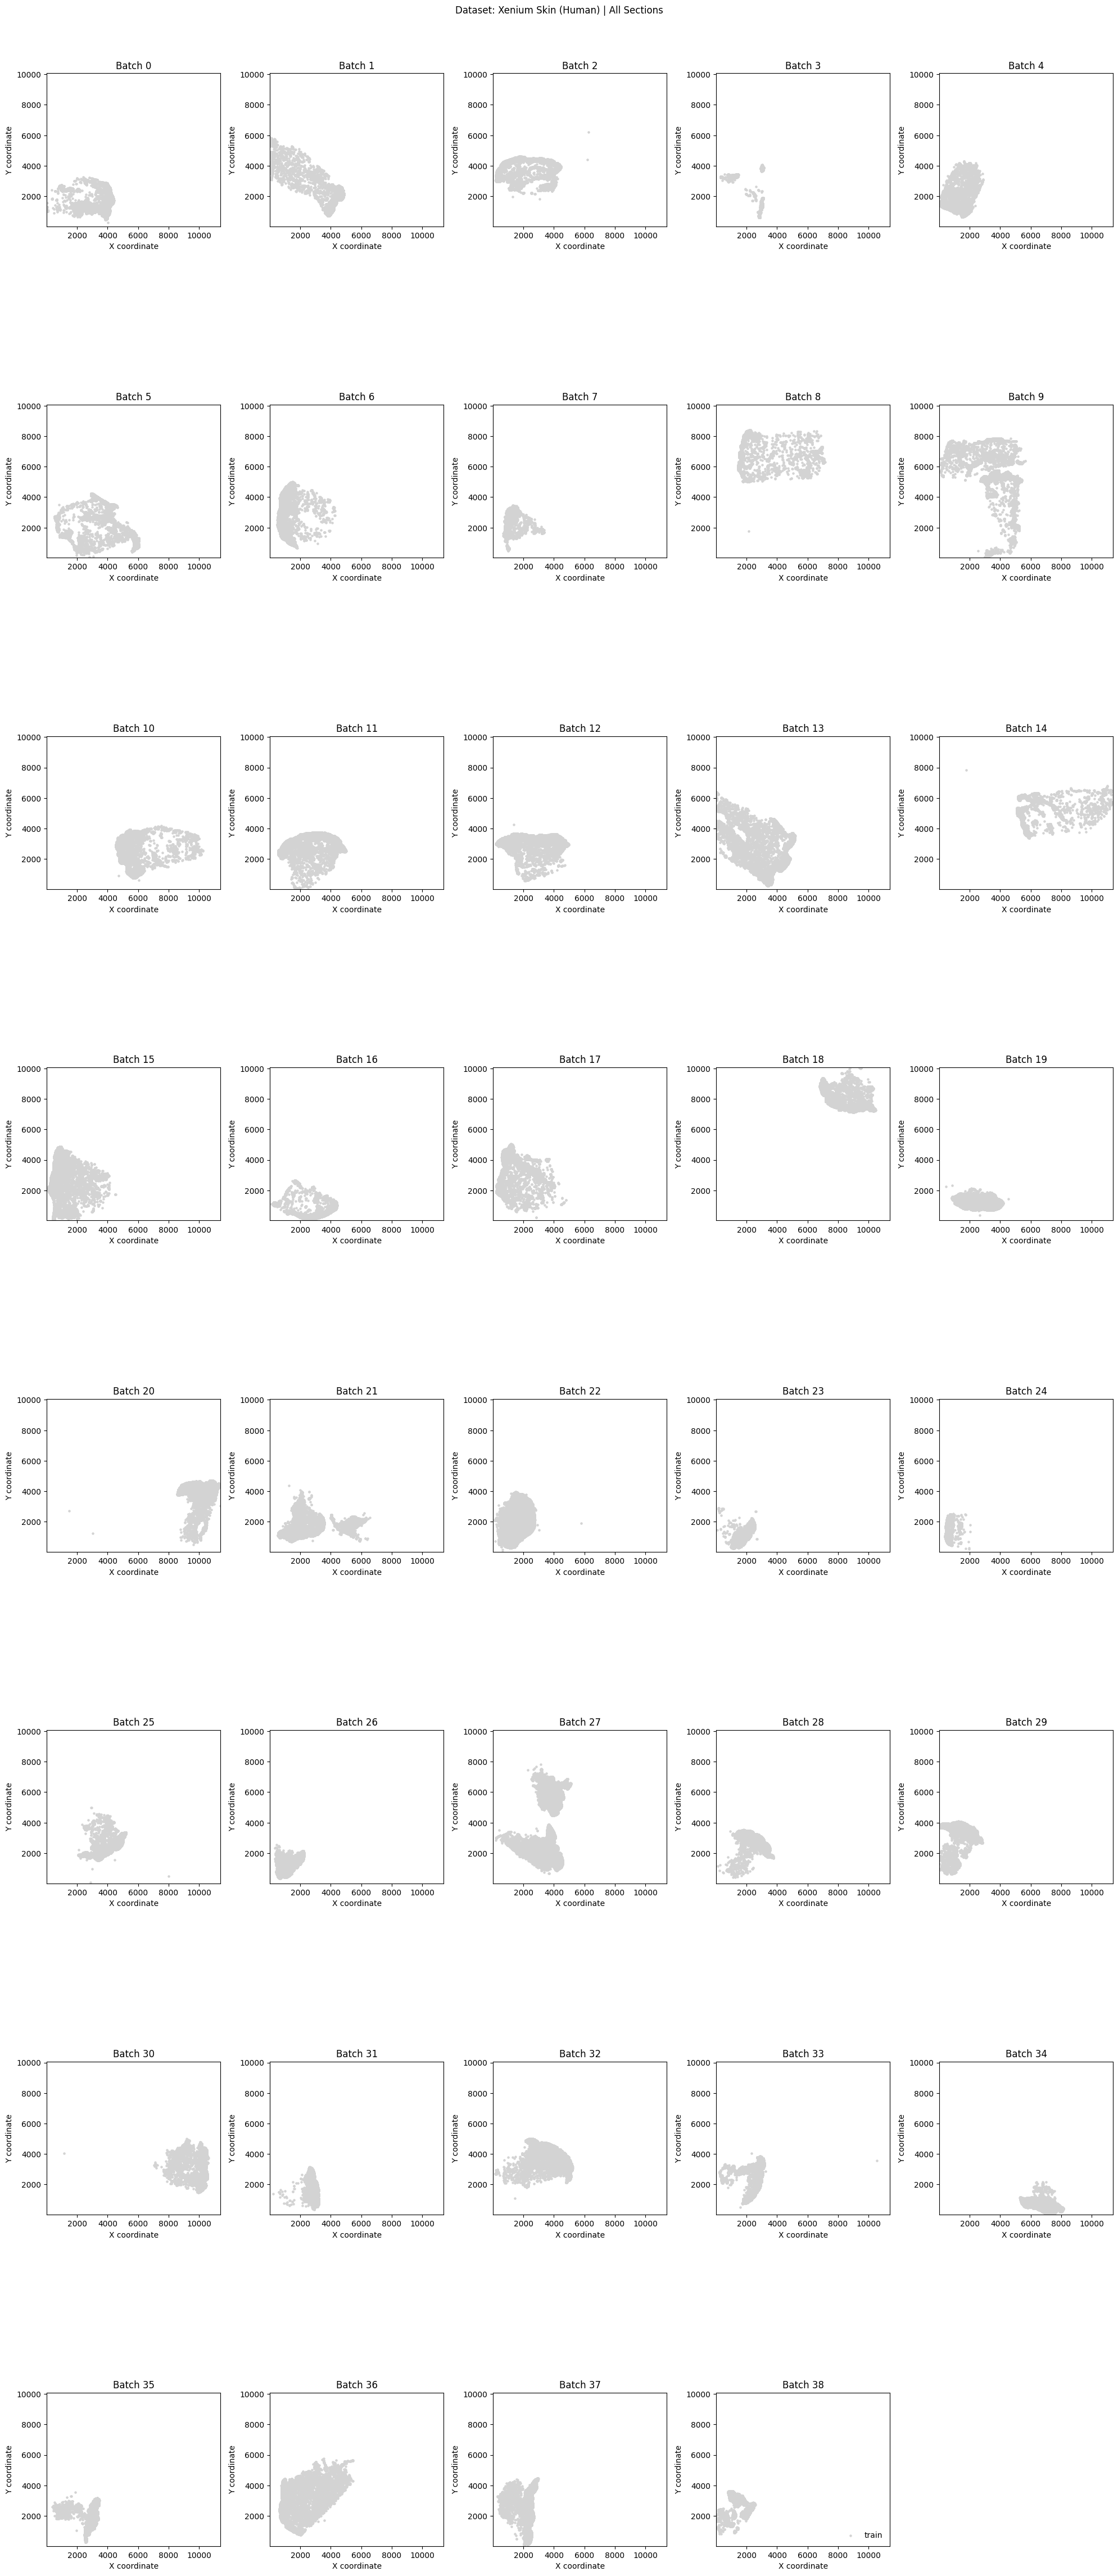

In [ ]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1000_39b_1p_all_sections_all_cells_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: All Batches'
)

# Dataset: Xenium Skin (Human) | Sections: Batch 2, 11, 12

## Random Split (80-10-10)

In [ ]:
xhs1000_39b_1p_oriented_3_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-oriented-3_random-split_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_oriented_3_rdn_file, 'r') as f:
    xhs1000_39b_1p_oriented_3_rdn_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1000_39b_1p_oriented_3_rdn_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_oriented_3_rdn_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_oriented_3_rdn_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[47765, 41], y_niche_types=[47765, 15], xy_coordinates=[47765, 2], cell_id=[3], dataset_id=[3], tissue=[3], species=[3], adata_batch_id=[3], x=[47765, 1000], y=[47765, 41], edge_index=[2, 494343], encoder_conditions=[47765, 48], encoder_condition_dim=48, spatial_prior_feature_dim=0, attr_decoder_conditions=[47765, 48], attr_decoder_condition_dim=48, adj_decoder_condition_dim=0, num_features=1000, num_classes=41, num_nodes=4

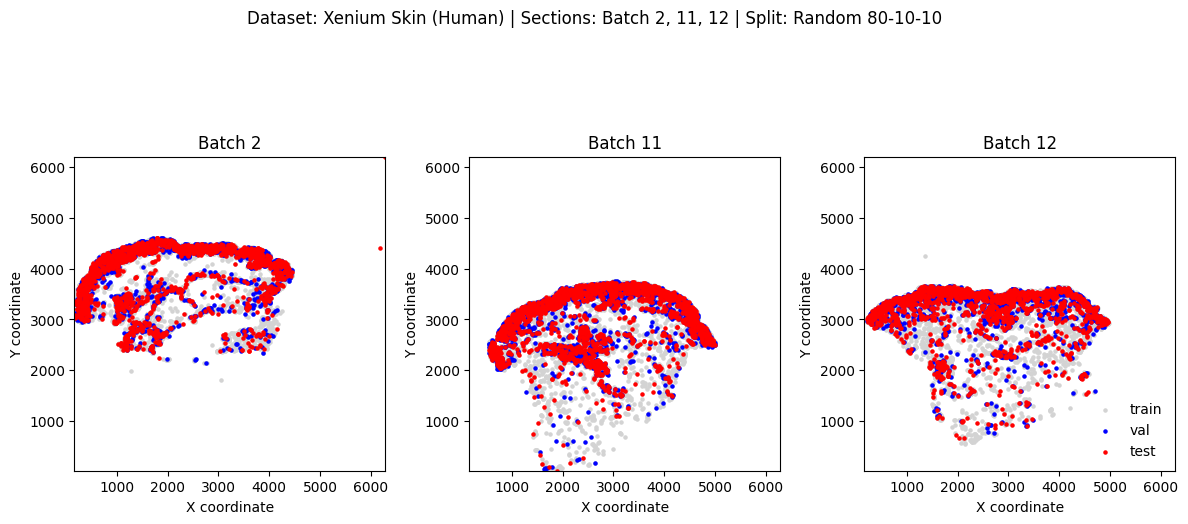

In [157]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1000_39b_1p_oriented_3_rdn_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: Batch 2, 11, 12 | Split: Random 80-10-10'
)

## 1-region Test | Sections: Batch 2, 11, 12

In [ ]:
xhs1000_39b_1p_oriented_3_1_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-oriented-3_1-test-patch-split_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_oriented_3_1_test_patch_file, 'r') as f:
    xhs1000_39b_1p_oriented_3_1_test_patch_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1000_39b_1p_oriented_3_1_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_oriented_3_1_test_patch_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_oriented_3_1_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[47765, 41], y_niche_types=[47765, 15], xy_coordinates=[47765, 2], cell_id=[3], dataset_id=[3], tissue=[3], species=[3], adata_batch_id=[3], x=[47765, 2000], y=[47765, 41], edge_index=[2, 494343], encoder_conditions=[47765, 48], encoder_condition_dim=48, spatial_prior_features=[47765, 8], spati

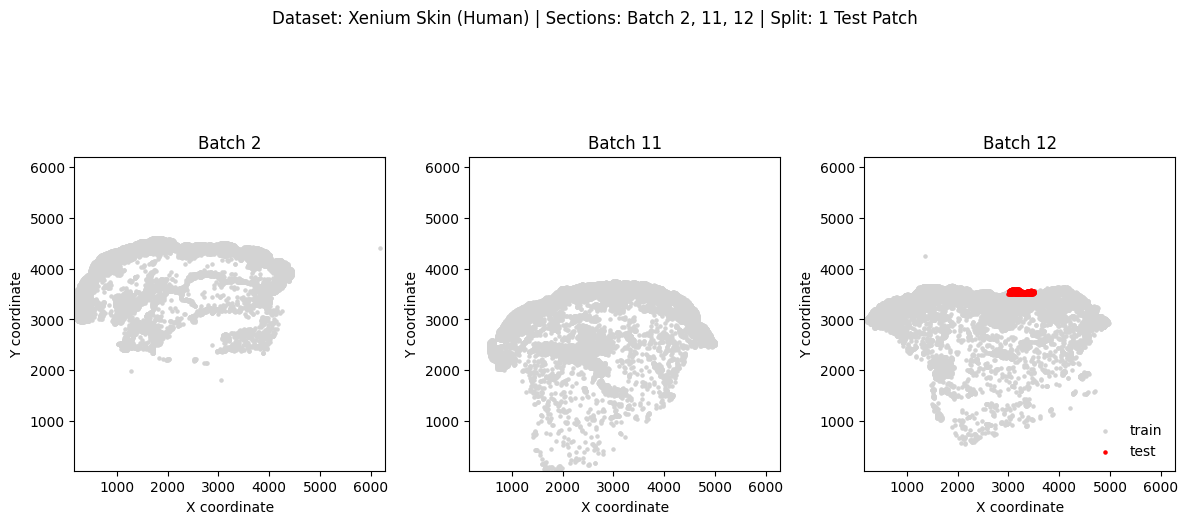

In [164]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1000_39b_1p_oriented_3_1_test_patch_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: Batch 2, 11, 12 | Split: 1 Test Patch'
)

## 3-region Test | Sections: Batch 2, 11, 12

In [ ]:
xhs1000_39b_1p_oriented_3_3_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-oriented-3_3-test-patch-split_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_oriented_3_3_test_patch_file, 'r') as f:
    xhs1000_39b_1p_oriented_3_3_test_patch_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1000_39b_1p_oriented_3_3_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_oriented_3_3_test_patch_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_oriented_3_3_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[47765, 41], y_niche_types=[47765, 15], xy_coordinates=[47765, 2], cell_id=[3], dataset_id=[3], tissue=[3], species=[3], adata_batch_id=[3], x=[47765, 2000], y=[47765, 41], edge_index=[2, 494343], encoder_conditions=[47765, 48], encoder_condition_dim=48, spatial_prior_features=[47765, 8], spati

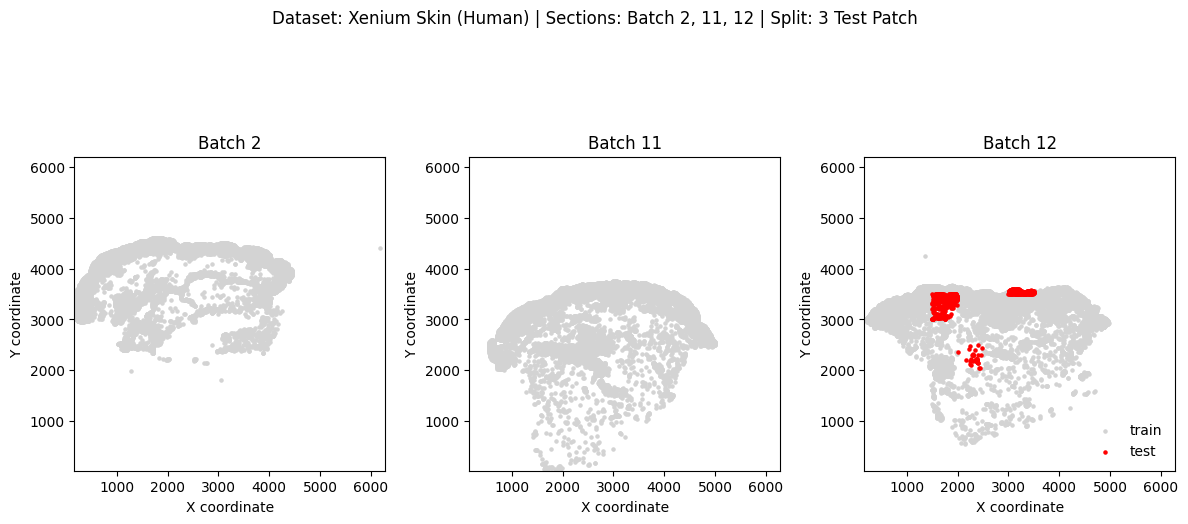

In [171]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1000_39b_1p_oriented_3_3_test_patch_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: Batch 2, 11, 12 | Split: 3 Test Patch'
)

# Dataset: Xenium Skin (Human) | Sections: Batch 2, 9, 11, 12, 28, 28, 32

## 3-region Test | Sections: Batch 2, 9, 11, 12, 28, 28, 32

In [8]:
xhs1000_39b_1p_oriented_7_3_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20250923-222431/wandb/offline-run-20250923_222431-mank50dk/files/user_specified_config.yaml")
with open(xhs1000_39b_1p_oriented_7_3_test_patch_file, 'r') as f:
    xhs1000_39b_1p_oriented_7_3_test_patch_cfg = yaml.safe_load(f)

In [9]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1000_39b_1p_oriented_7_3_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_oriented_7_3_test_patch_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_oriented_7_3_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
SubsetHVG: Subsetted data to 1000 features.
DataBatch(y_cell_types=[110278, 41], y_niche_types=[110278, 15], xy_coordinates=[110278, 2], cell_id=[7], dataset_id=[7], tissue=[7], species=[7], adata_batch_id=[7], x=[110278, 1000], y=[110278, 41], edge_index=[2, 1141520], encoder_condition_dim=0, spatial_prior_feature_dim=0, attr_decoder_condition_dim=0, adj_decoder_condition_dim=0, num_features=1000, num_classes=41, num_nodes=110278, num_edges=[7], train_mask=[110278], val_mask=[110278], test_mask=[110278], batch=[110278], ptr=[8], adata_batch_ids=[110278])
Batch ID(s): [2, 11, 9, 28, 29, 32, 12]
Data Batch: DataBatch(y_cell_types=[110278, 41], y_niche_types=[110278, 15], xy_coordina

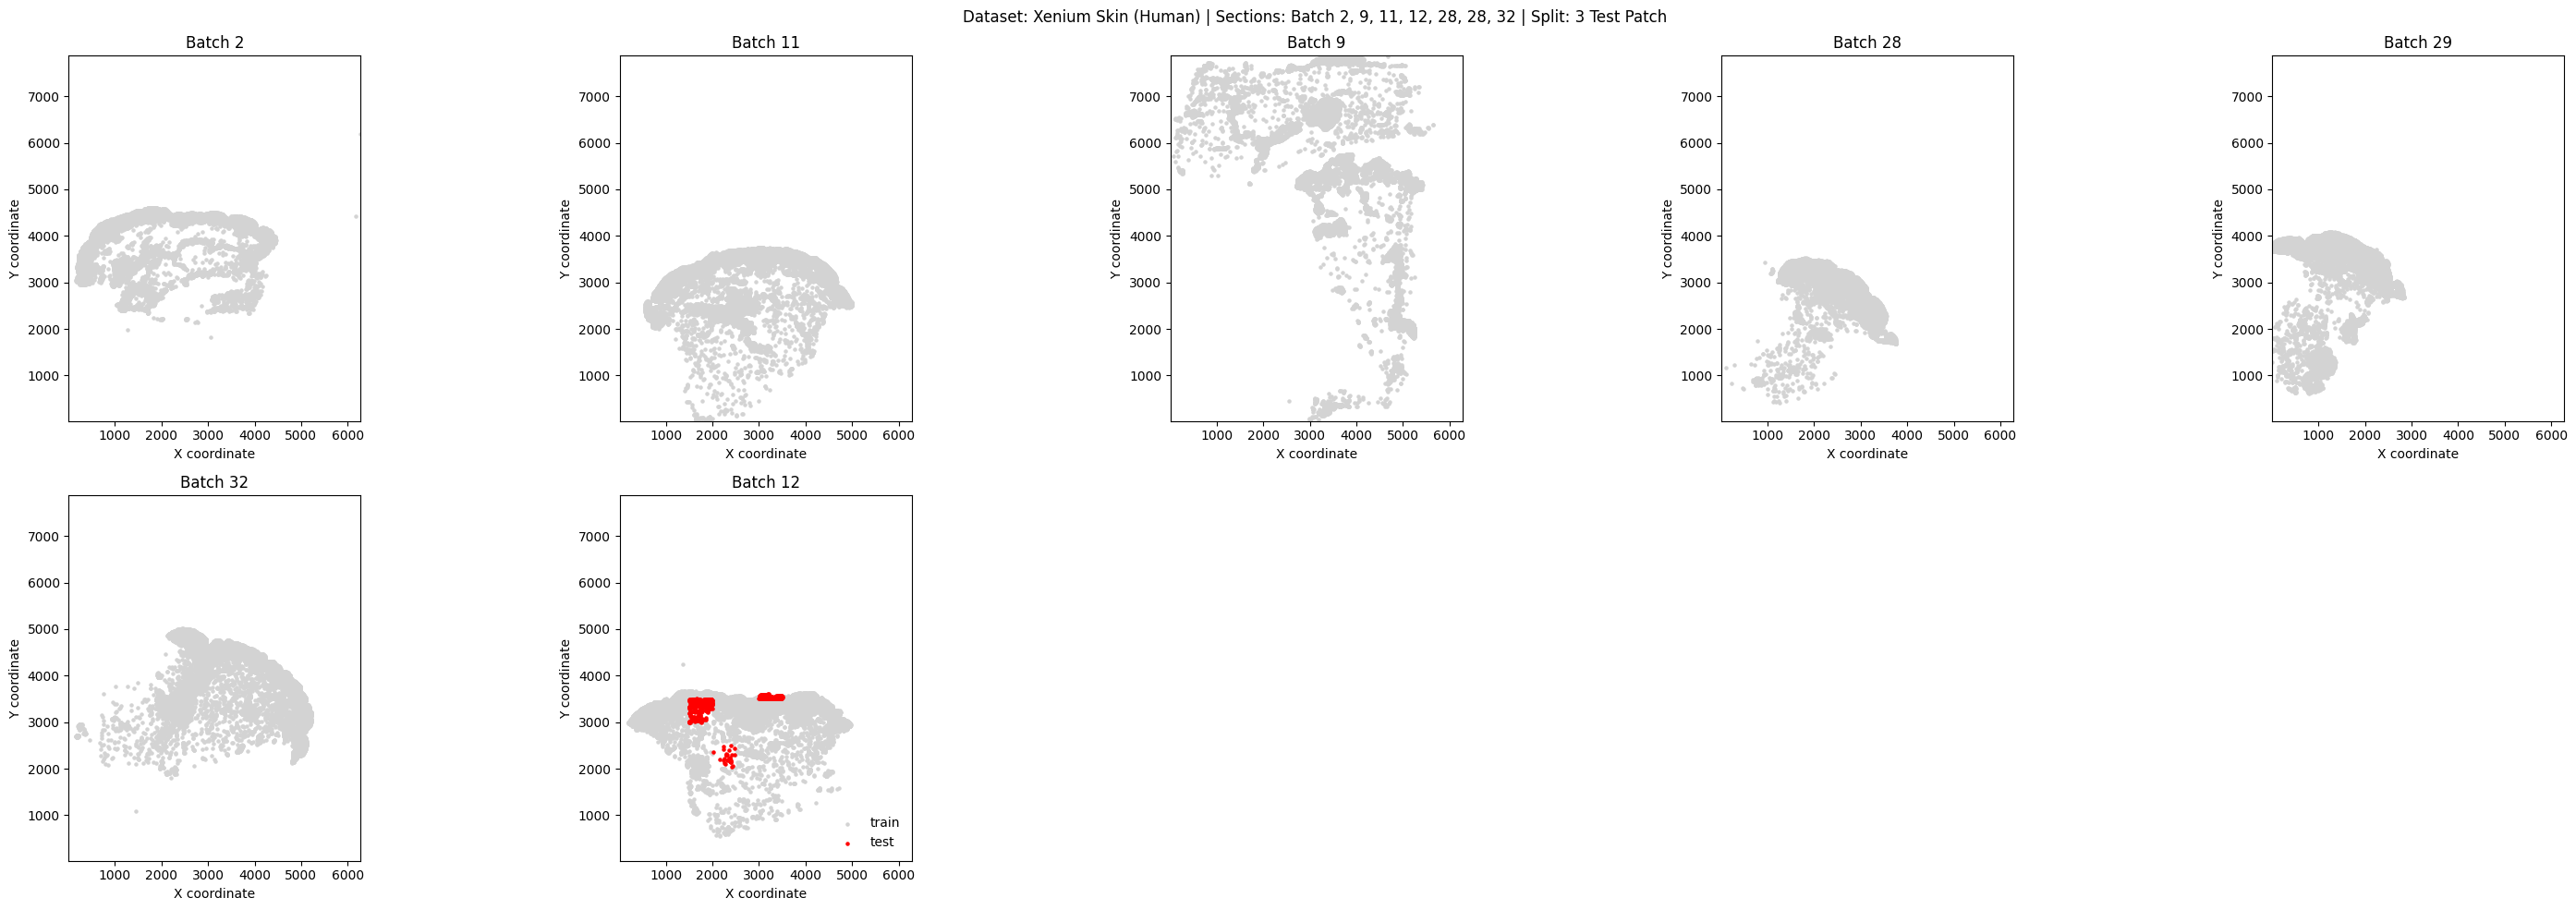

In [10]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1000_39b_1p_oriented_7_3_test_patch_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: Batch 2, 9, 11, 12, 28, 28, 32 | Split: 3 Test Patch'
)

# Patient BK21 | Sections: Batch 14, 2, 5, 10, 16

In [ ]:
xhs1000_39b_1p_patientBK21_all_cells_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1000-39b_1p-patient-BK21_all-cells_vqniche_graphsage.yaml")
with open(xhs1000_39b_1p_patientBK21_all_cells_file, 'r') as f:
    xhs1000_39b_1p_patientBK21_all_cells_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1000_39b_1p_patientBK21_all_cells_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1000_39b_1p_patientBK21_all_cells_data_batch = initialize_databatch(
    config=xhs1000_39b_1p_patientBK21_all_cells_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 2000 features.
Setting section-level conditioning features for encoder.
Setting spatial prior features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[44145, 41], y_niche_types=[44145, 15], xy_coordinates=[44145, 2], cell_id=[4], dat

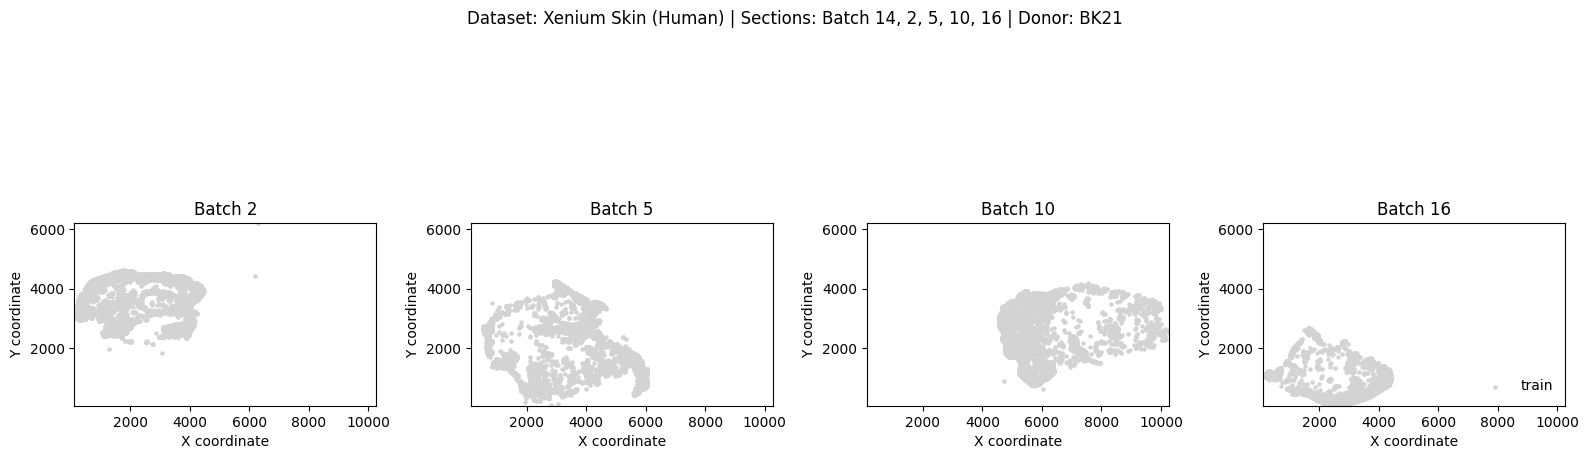

In [174]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1000_39b_1p_patientBK21_all_cells_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: Batch 14, 2, 5, 10, 16 | Donor: BK21'
)

# Dataset: Xenium Kidney (Human) | Sections: All 5 batches

In [11]:
xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhk1020-CV1-CV2-5b_1p_3-test-patch-split_vqniche_graphsage.yaml")
with open(xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_file, 'r') as f:
    xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_cfg = yaml.safe_load(f)

In [12]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_data_batch = initialize_databatch(
    config=xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_grade=[260193, 2], y_clinical_risk=[260193, 2], xy_coordinates=[260193, 2], cell_id=[5], dataset_id=[5

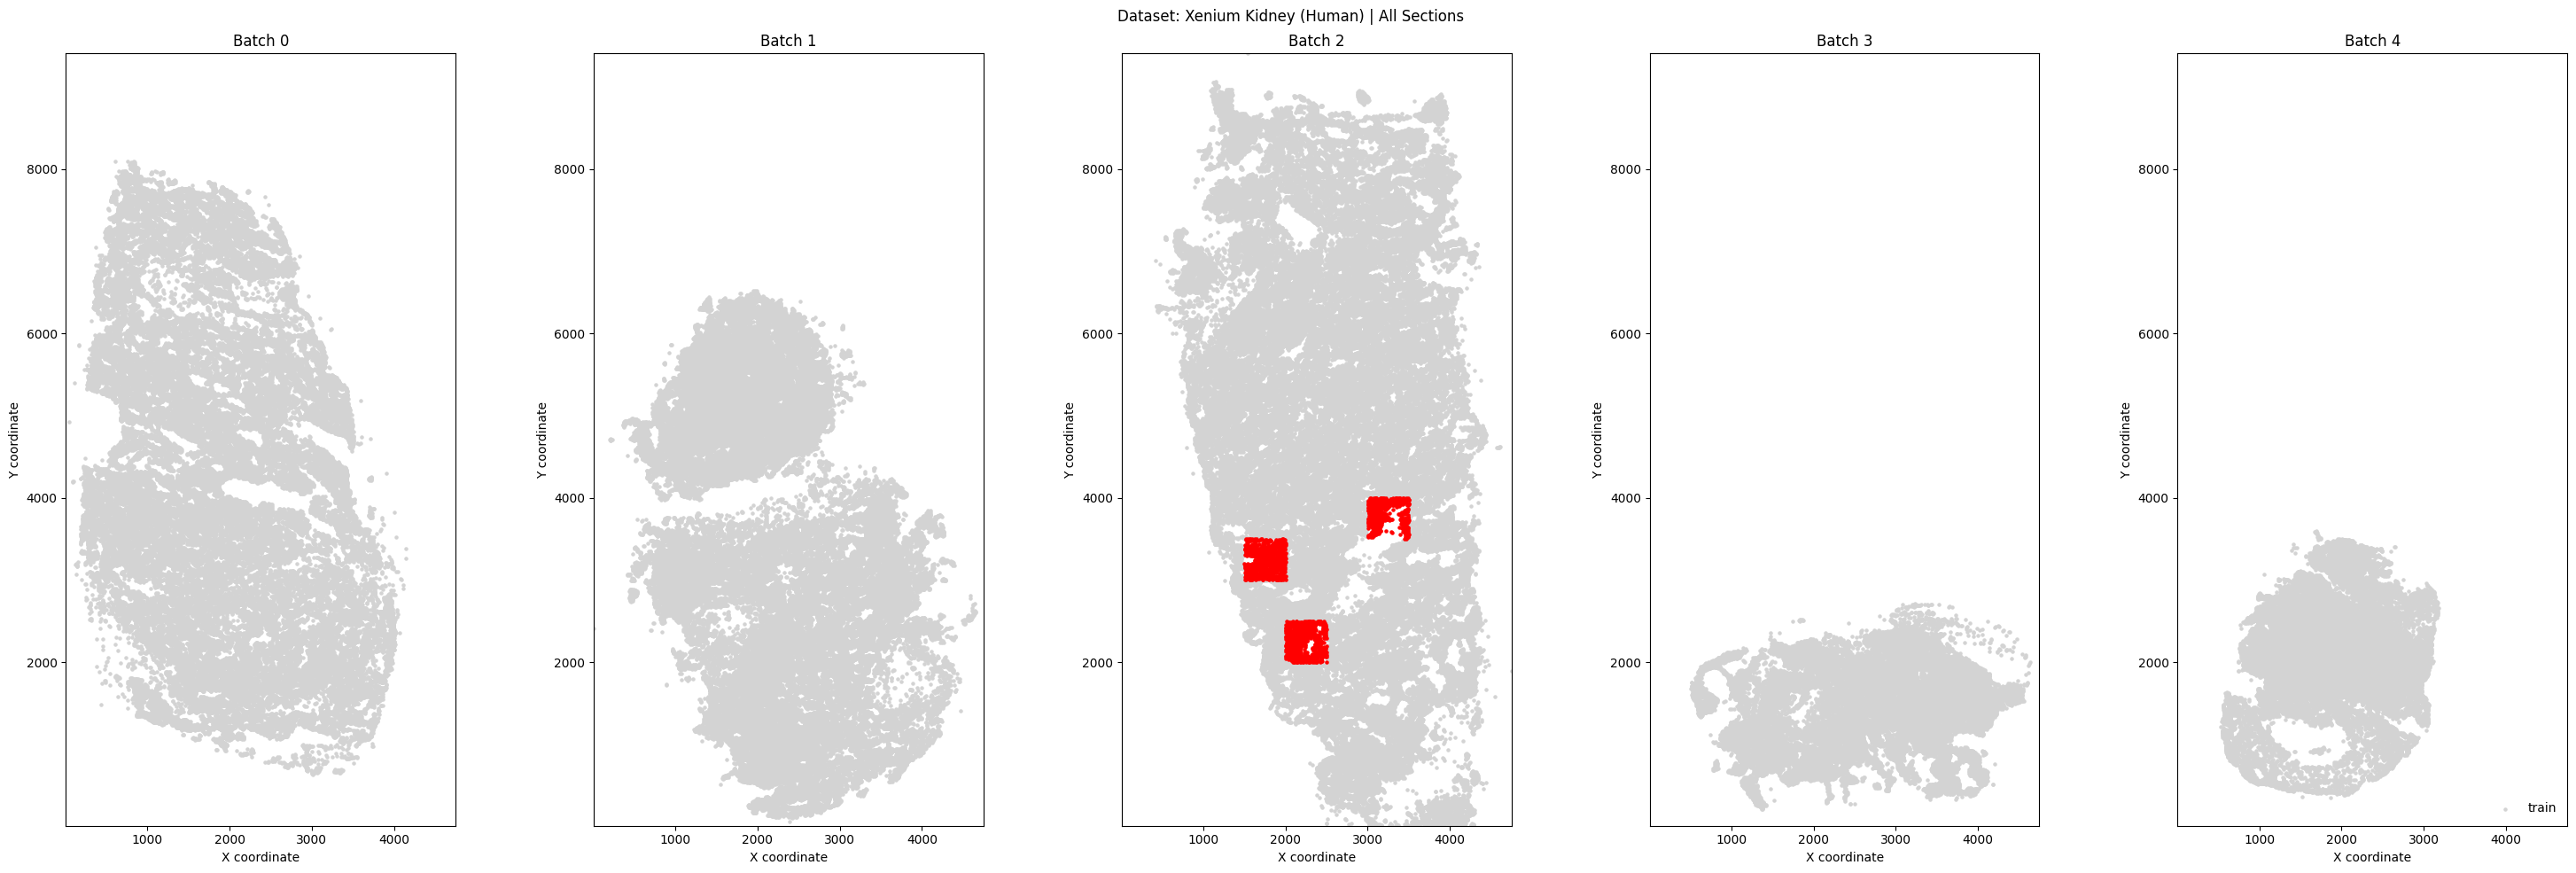

In [19]:
multiple_sections_train_val_test_splits(
    data_batch=xhk1020_CV1_CV2_5b_1p_all_sections_all_cells_data_batch,
    title='Dataset: Xenium Kidney (Human) | All Sections',
    height=10,
    fname="kidney_train-test_split.pdf"
)

# Dataset: Simulated 10K | Sections: Batch 1

## Random Split (80-10-10)

In [ ]:
sss2_1b_1p_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/sss2-1b_1p_random-split_vqniche_graphsage.yaml")
with open(sss2_1b_1p_rdn_file, 'r') as f:
    sss2_1b_1p_rdn_cfg = yaml.safe_load(f)

In [13]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(sss2_1b_1p_rdn_cfg)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
sss2_1b_1p_rdn_data_batch = initialize_databatch(
    config=sss2_1b_1p_rdn_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[10000, 8], y_niche_types=[10000, 8], xy_coordinates=[10000, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[10000, 1000], y=[10000, 8], edge_index=[2, 102480], encoder_conditions=[10000, 8], encoder_condition_dim=8, spatial_prior_feature_dim=0, attr_decoder_conditions=[10000, 8], attr_decoder_condition_dim=8, adj_decoder_condition_dim=0, num_features=1000, num_classes=8, num_nodes=10000, num_edges=[1], train_mask=[10000], val_mask=[10000], test_mask=[10000], batch=[10000], ptr=[2], adata_batch_ids=[10000])
Batch ID(s): [0]
Data Batch: DataBatch(y_cell_types=[10000, 8], y_niche_types=[10000, 8], xy_coordinates=[10000, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[10000, 1000], y=[10000,

Extracting data attributes...
Data batch keys: ['xy_coordinates', 'train_mask', 'attr_decoder_condition_dim', 'val_mask', 'attr_decoder_conditions', 'cell_id', 'adata_batch_ids', 'edge_index', 'adata_batch_id', 'encoder_conditions', 'num_nodes', 'num_features', 'num_edges', 'y_cell_types', 'test_mask', 'spatial_prior_feature_dim', 'dataset_id', 'species', 'ptr', 'num_classes', 'x', 'tissue', 'encoder_condition_dim', 'adj_decoder_condition_dim', 'y', 'batch', 'y_niche_types']
Number of nodes: 10000
Number of features: 1000
Number of edges: 102480
Train nodes: 8000
Val nodes: 1000
Test nodes: 1000
Total nodes: 10000


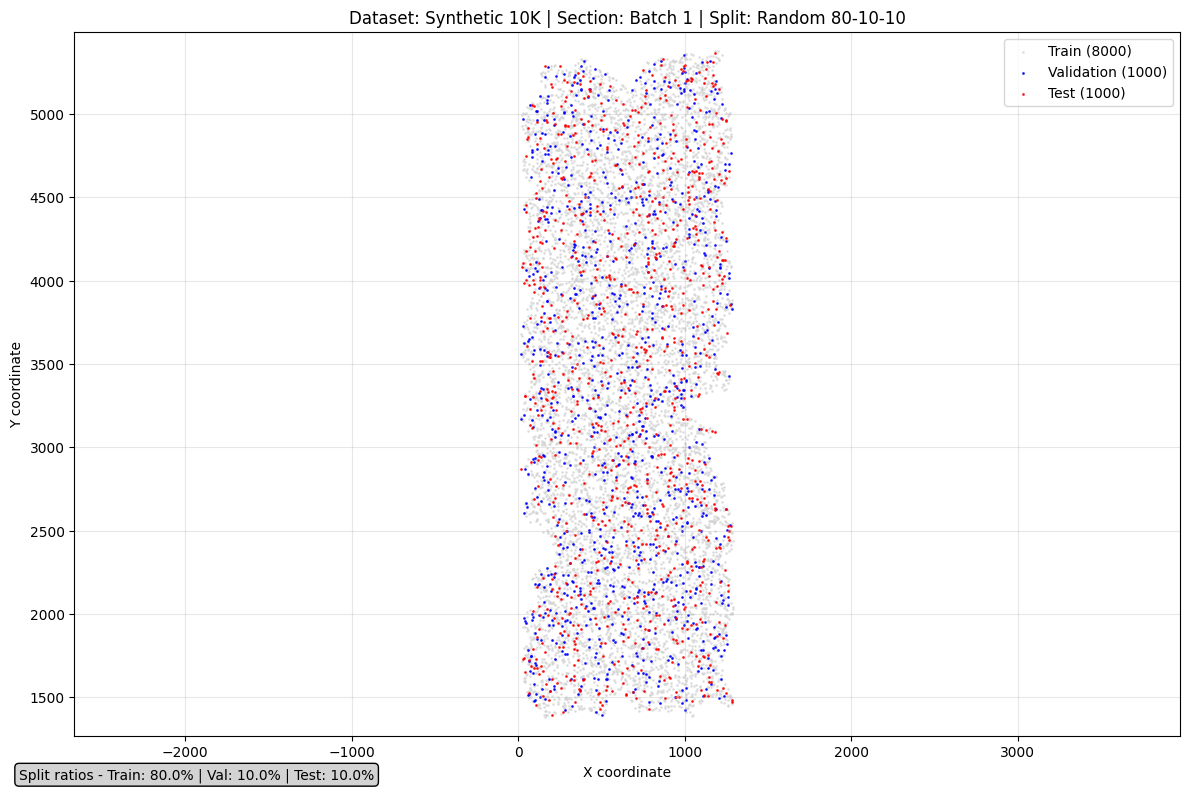

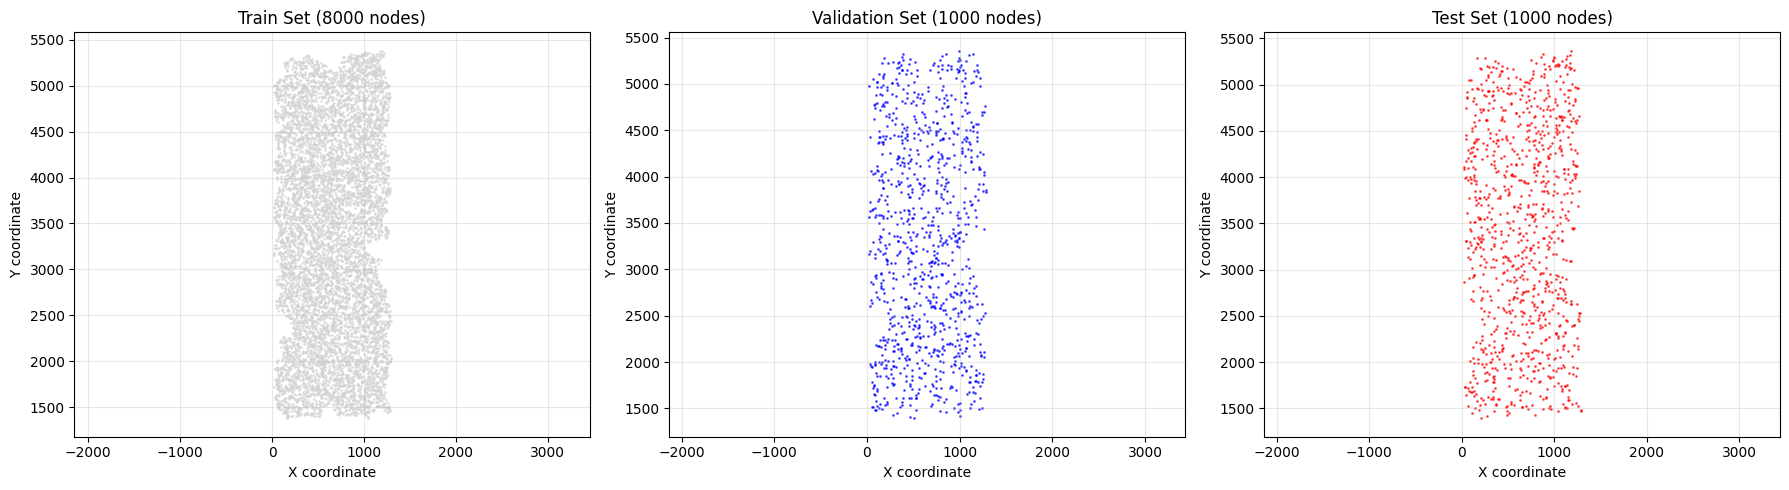

In [14]:
one_section_train_val_test_splits(
    data_batch=sss2_1b_1p_rdn_data_batch,
    title='Dataset: Synthetic 10K | Section: Batch 1 | Split: Random 80-10-10'
)

## 1-region Test | Sections: Batch 1

In [ ]:
sss2_1b_1p_1_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/sss2-1b_1p_1-test-patch-split_vqniche_graphsage.yaml")
with open(sss2_1b_1p_1_test_patch_file, 'r') as f:
    sss2_1b_1p_1_test_patch_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    sss2_1b_1p_1_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
sss2_1b_1p_1_test_patch_data_batch = initialize_databatch(
    config=sss2_1b_1p_1_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SpatialNodeSplit: Train=8589, Val=0, Test=1411
Total nodes assigned: 10000/10000
DataBatch(y_cell_types=[10000, 8], y_niche_types=[10000, 8], xy_coordinates=[10000, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[10000, 1000], y=[10000, 8], edge_index=[2, 102480], encoder_conditions=[10000, 8], encoder_condition_dim=8, spatial_prior_feature_dim=0, attr_decoder_conditions=[10000, 8], attr_decoder_condition_dim=8, adj_decoder_condition_dim=0, num_features=1000, num_classes=8, num_nodes=10000, num_edges=[1], train_mask=[10000], val_mask=[10000], test_mask=[10000], batch=[10000], ptr=[2], adata_batch_ids=[10000])
Batch ID(s): [0]
Data Batch: DataBatch(y_cell_types=[10000, 8], y_niche_types=[10000, 8], xy_coordinates=[10000, 2], cell_id=[1], datase

In [ ]:
multiple_sections_train_val_test_splits(
    data_batch=sss2_1b_1p_1_test_patch_data_batch,
    title='Dataset: Xenium Skin (Human) | Sections: Batch 1 | Split: 1 Test Patch'
)

# Dataset: Xenium Brain (Mouse) | Sections: Batches 0, 1, 2, 3

## Random Split (80-10-10)

In [ ]:
mmb0_4b_1p_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/mmb0-4b_1p_random-split_vqniche_graphsage.yaml")
with open(mmb0_4b_1p_rdn_file, 'r') as f:
    mmb0_4b_1p_rdn_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    mmb0_4b_1p_rdn_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
mmb0_4b_1p_rdn_data_batch = initialize_databatch(
    config=mmb0_4b_1p_rdn_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[48156, 23], y_niche_types=[48156, 4], xy_coordinates=[48156, 2], cell_id=[4], dataset_id=[4], tissue=[4], species=[4], adata_batch_id=[4], x=[48156, 1000], y=[48156, 23], edge_index=[2, 497936], encoder_conditions=[48156, 13], encoder_condition_dim=13, spati

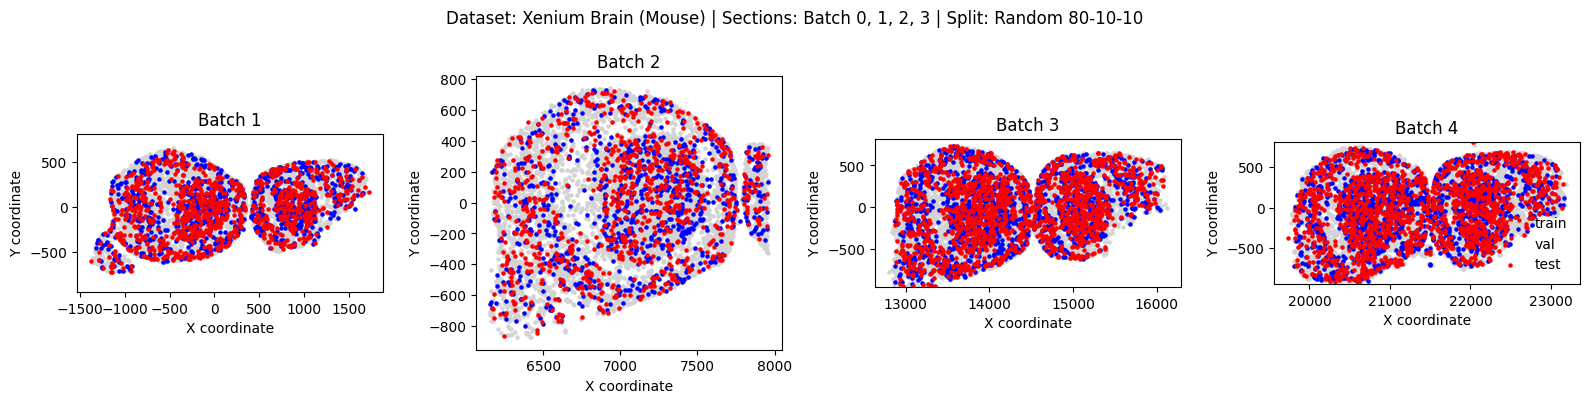

In [71]:
multiple_sections_train_val_test_splits(
    data_batch=mmb0_4b_1p_rdn_data_batch,
    title='Dataset: Xenium Brain (Mouse) | Sections: Batch 0, 1, 2, 3 | Split: Random 80-10-10',
    height=4,
    width=4,
    xlim=-1
)

## 1-region Test

In [ ]:
mmb0_4b_1p_1_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/mmb0-4b_1p_1-test-patch-split_vqniche_graphsage.yaml")
with open(mmb0_4b_1p_1_test_patch_file, 'r') as f:
    mmb0_4b_1p_1_test_patch_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    mmb0_4b_1p_1_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
mmb0_4b_1p_1_test_patch_data_batch = initialize_databatch(
    config=mmb0_4b_1p_1_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[48156, 23], y_niche_types=[48156, 4], xy_coordinates=[48156, 2], cell_id=[4], dataset_id=[4], tissue=[4], species=[4], adata_batch_id=[4], x=[48156, 1000], y=[48156, 23], edge_index=[2, 497936], encoder_conditions=[48156, 13], encoder_condition_dim=13, spati

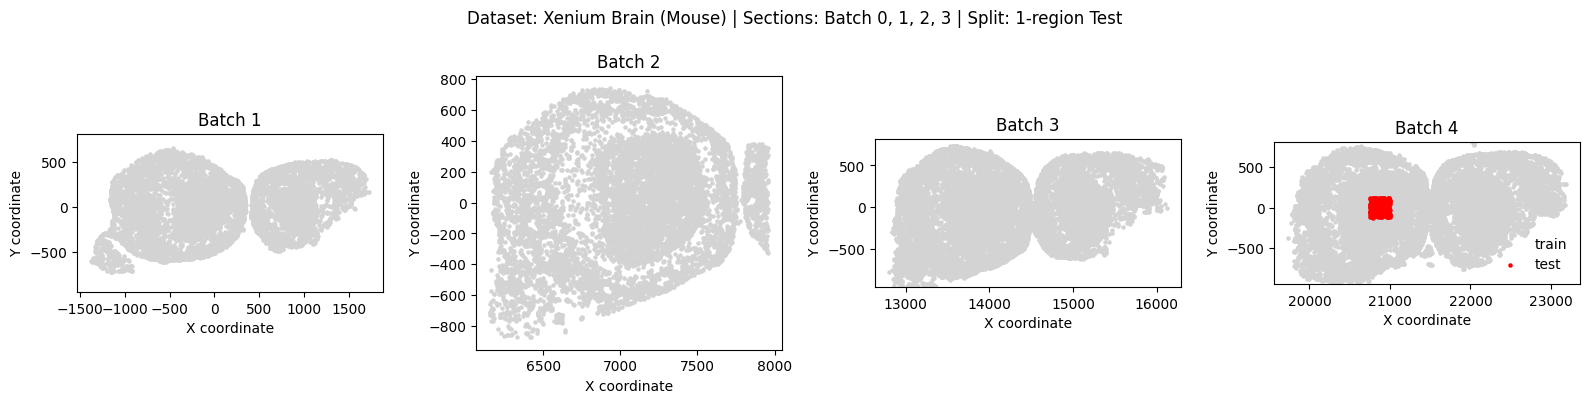

In [80]:
multiple_sections_train_val_test_splits(
    data_batch=mmb0_4b_1p_1_test_patch_data_batch,
    title='Dataset: Xenium Brain (Mouse) | Sections: Batch 0, 1, 2, 3 | Split: 1-region Test',
    height=4,
    width=4,
    xlim=-1
)

## 3-region Test

In [23]:
mmb0_4b_1p_3_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/mmb0-4b_1p_3-test-patch-split_vqniche_graphsage.yaml")
with open(mmb0_4b_1p_3_test_patch_file, 'r') as f:
    mmb0_4b_1p_3_test_patch_cfg = yaml.safe_load(f)

In [24]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    mmb0_4b_1p_3_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
mmb0_4b_1p_3_test_patch_data_batch = initialize_databatch(
    config=mmb0_4b_1p_3_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
DataBatch(y_cell_types=[48156, 23], y_niche_types=[48156, 4], xy_coordinates=[48156, 2], cell_id=[4], dataset_id=[4], tissue=[4], species=[4], adata_batch_id=[4], x=[48156, 1000], y=[48156, 23], edge_index=[2, 497936], encoder_conditions=[48156, 13], encoder_condition_dim=13, spati

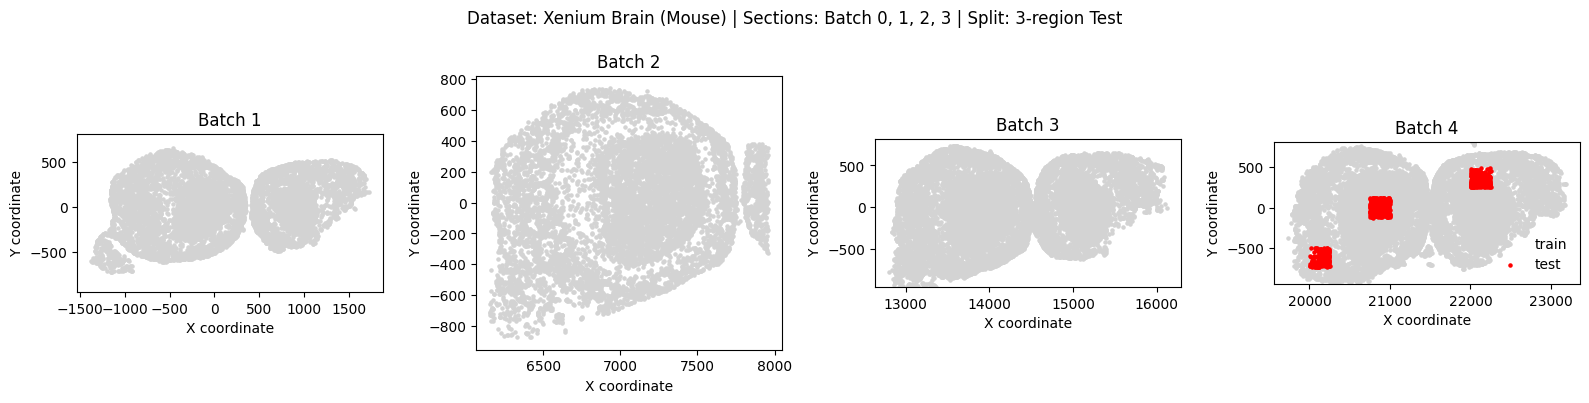

In [25]:
multiple_sections_train_val_test_splits(
    data_batch=mmb0_4b_1p_3_test_patch_data_batch,
    title='Dataset: Xenium Brain (Mouse) | Sections: Batch 0, 1, 2, 3 | Split: 3-region Test',
    height=4,
    width=4,
    xlim=-1,
    fname="brain_train-test_split.pdf"
)

# Dataset: Xenium Skin 3D (Human) | Sections: 1 to 15

## Random Split (80-10-10)

In [7]:
xhs1021_15b_1p_rdn_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1021-15b_1p_random-split_vqniche_graphsage.yaml")
with open(xhs1021_15b_1p_rdn_file, 'r') as f:
    xhs1021_15b_1p_rdn_cfg = yaml.safe_load(f)

In [8]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1021_15b_1p_rdn_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1021_15b_1p_rdn_data_batch = initialize_databatch(
    config=xhs1021_15b_1p_rdn_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting secti

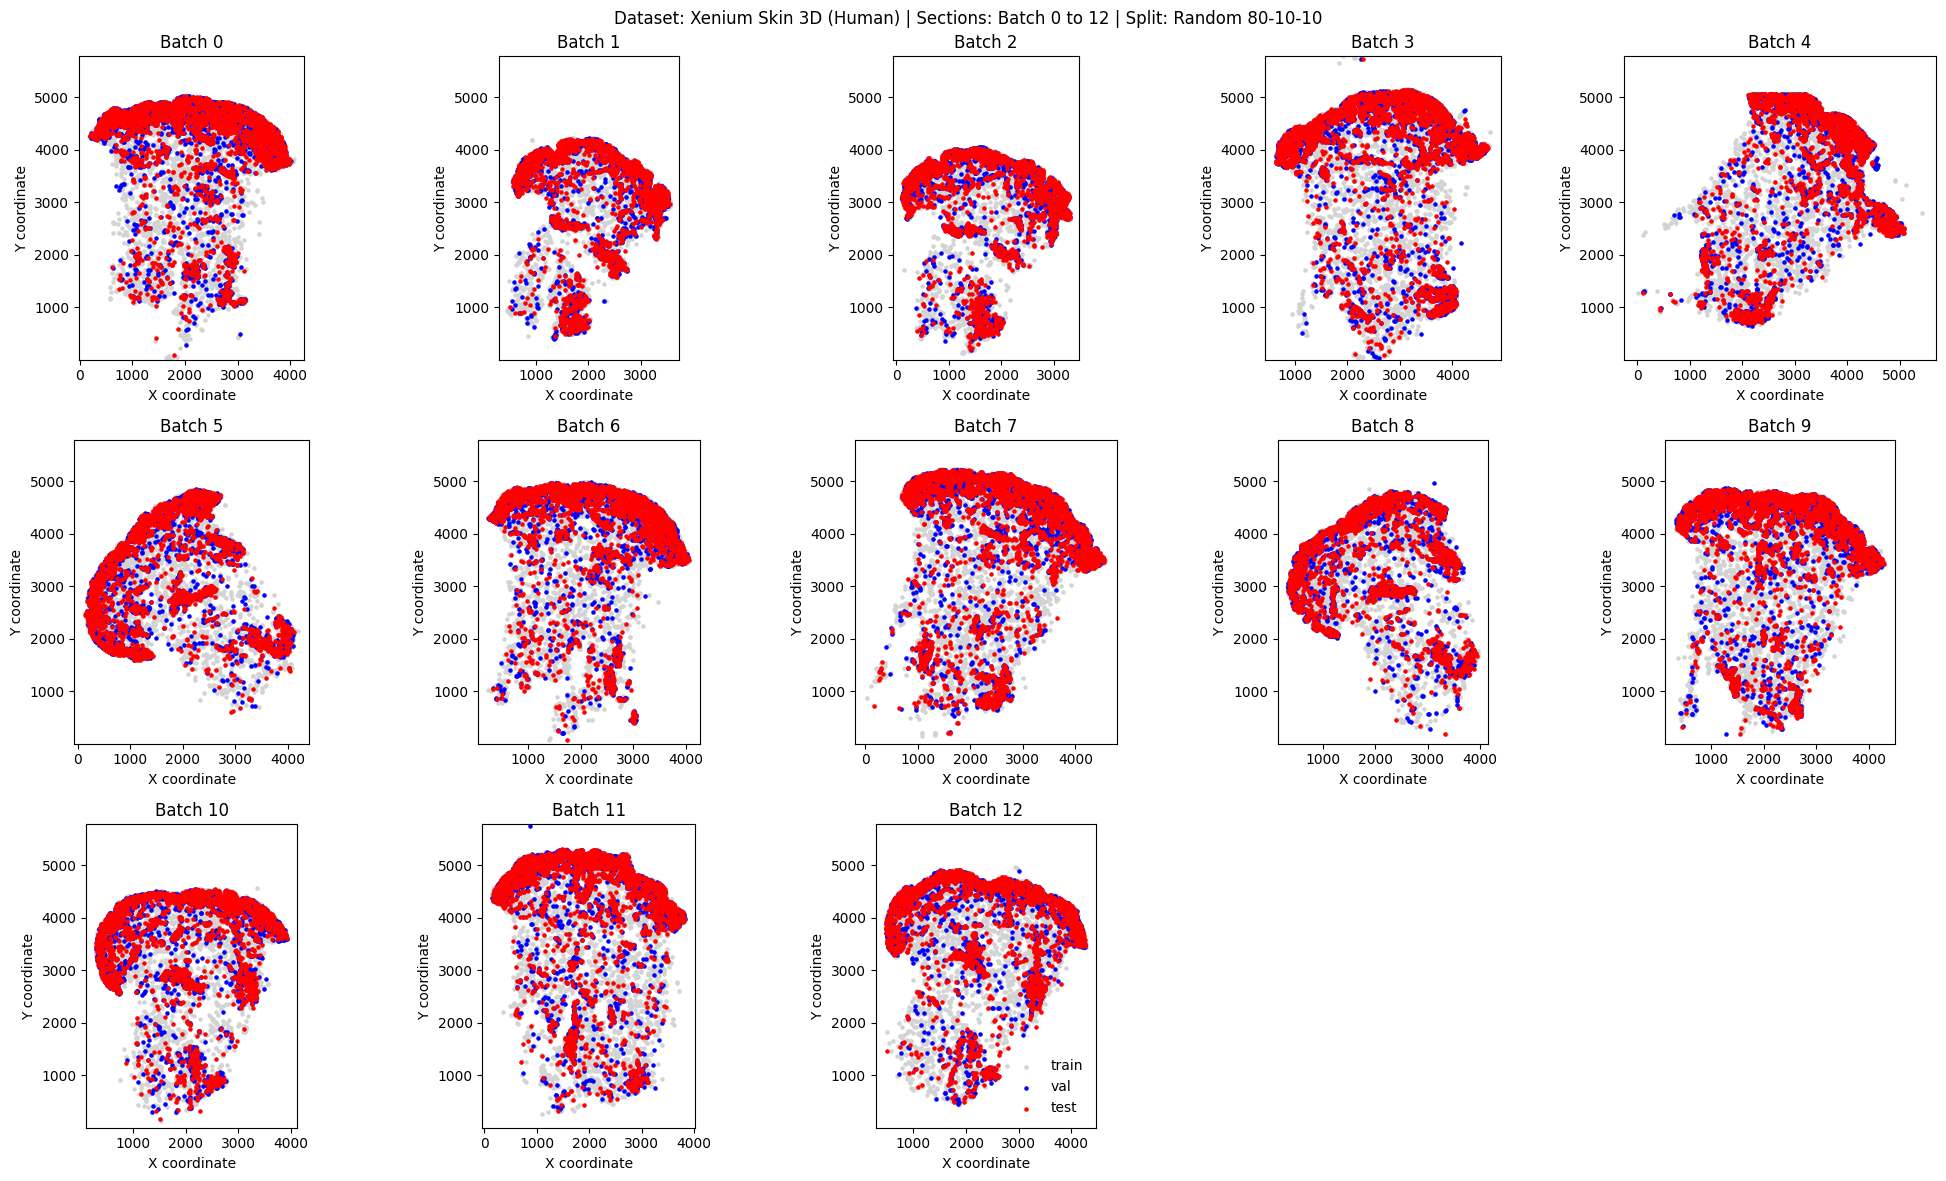

In [9]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1021_15b_1p_rdn_data_batch,
    title='Dataset: Xenium Skin 3D (Human) | Sections: Batch 0 to 12 | Split: Random 80-10-10',
    height=4,
    width=4,
    xlim=-1
)

## 1-region Test

In [ ]:
xhs1021_15b_1p_1_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1021-15b_1p_1-test-patch-split_vqniche_graphsage.yaml")
with open(xhs1021_15b_1p_1_test_patch_file, 'r') as f:
    xhs1021_15b_1p_test_patch_cfg = yaml.safe_load(f)

In [ ]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1021_15b_1p_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1021_15b_1p_test_patch_data_batch = initialize_databatch(
    config=xhs1021_15b_1p_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting secti

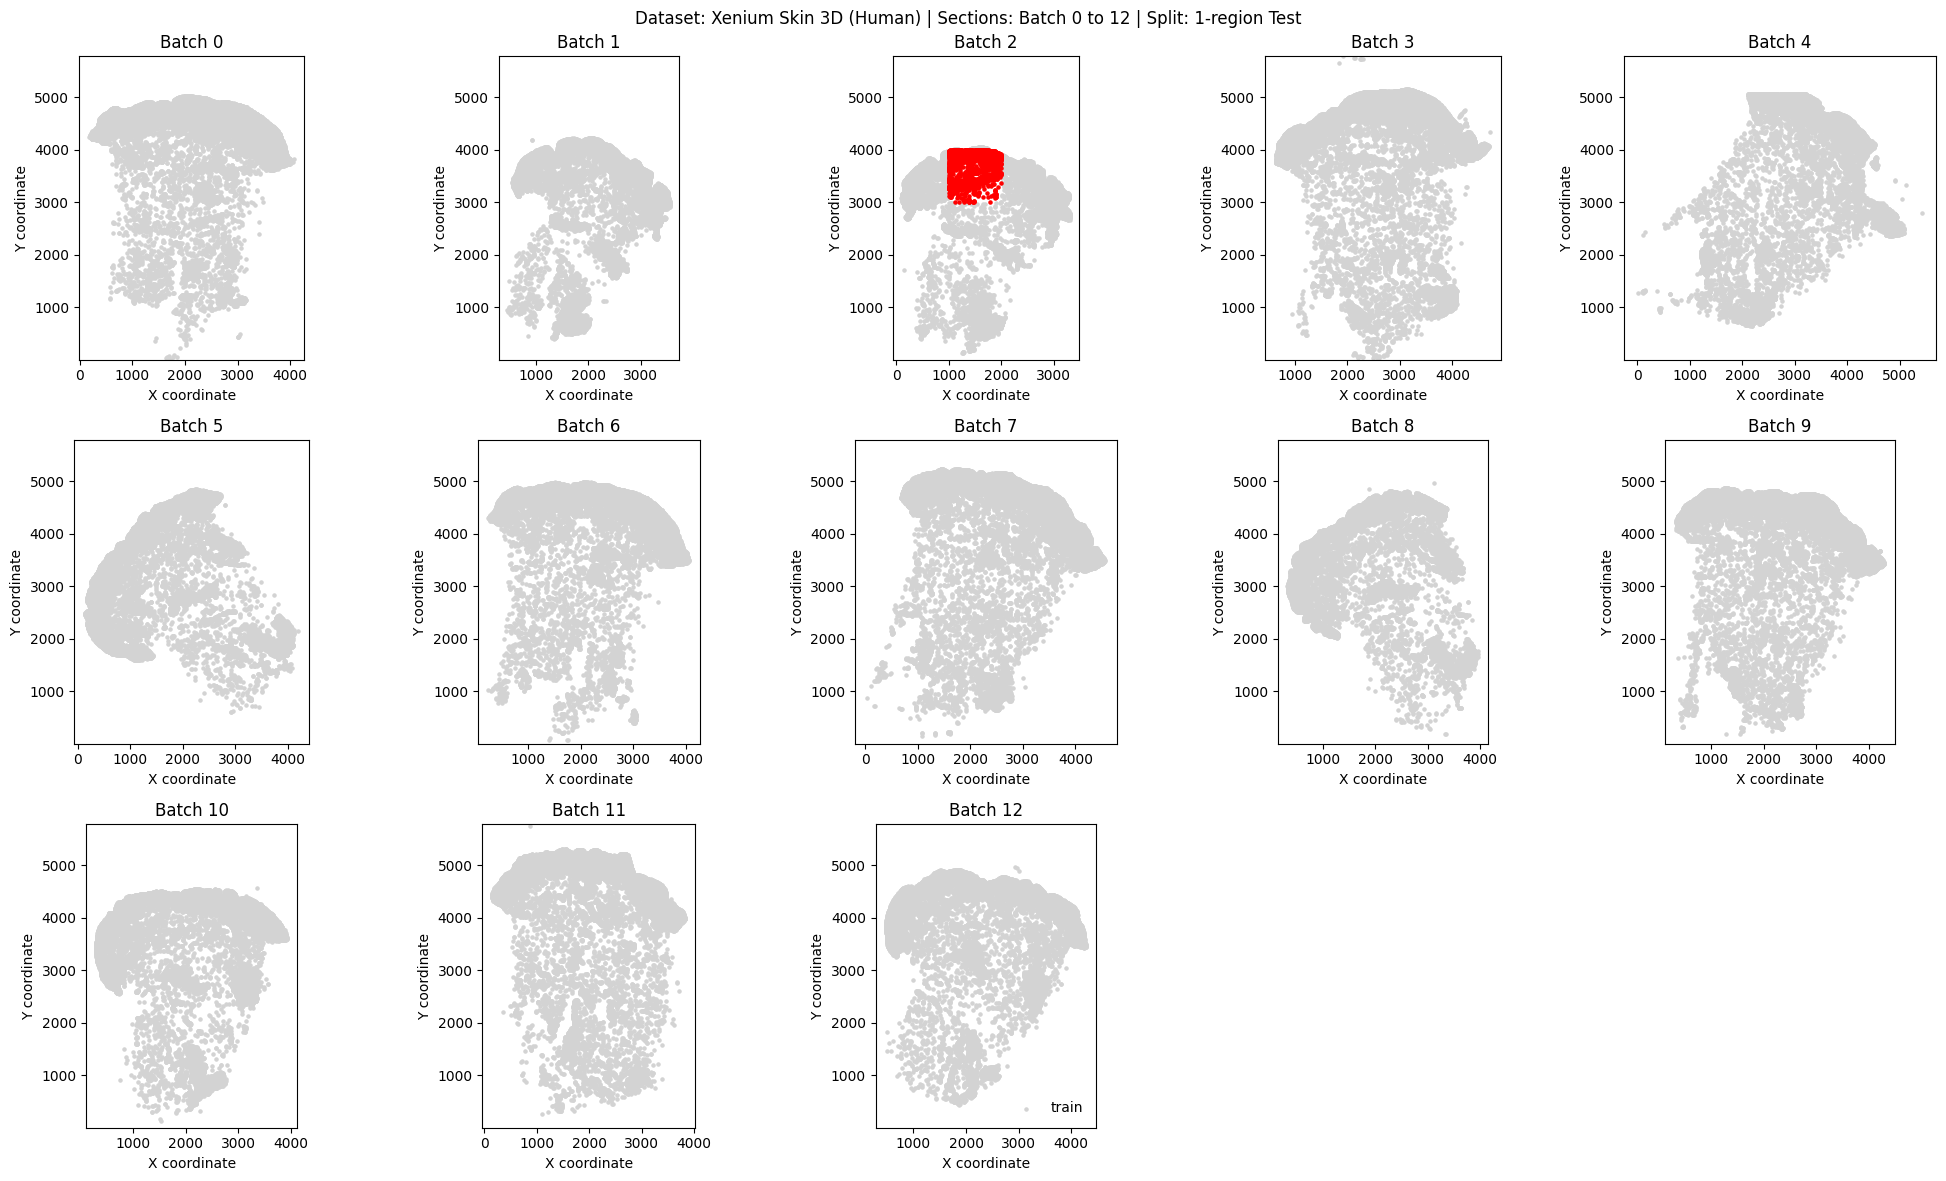

In [13]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1021_15b_1p_test_patch_data_batch,
    title='Dataset: Xenium Skin 3D (Human) | Sections: Batch 0 to 12 | Split: 1-region Test',
    height=4,
    width=4,
    xlim=-1
)

## 3-region Test

In [10]:
xhs1021_15b_1p_3_test_patch_file = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/reproducibility/config/train_model/xhs1021-15b_1p_3-test-patch-split_vqniche_graphsage.yaml")
with open(xhs1021_15b_1p_3_test_patch_file, 'r') as f:
    xhs1021_15b_1p_3_test_patch_cfg = yaml.safe_load(f)

In [11]:
print("Loading dataset...")
# Initialize dataset blob (this loads the raw data and applies transforms)
dataset_blob = initialize_dataset_blob(
    xhs1021_15b_1p_3_test_patch_cfg
)

print("Initializing data batch...")
# Initialize data batch (this loads the specific batch/tissue section)
xhs1021_15b_1p_3_test_patch_data_batch = initialize_databatch(
    config=xhs1021_15b_1p_3_test_patch_cfg,
    dataset_blob=dataset_blob
)

Loading dataset...
Initializing data batch...
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting section-level conditioning features for attribute decoder.
SubsetHVG: Subsetted data to 1000 features.
Setting section-level conditioning features for encoder.
Setting secti

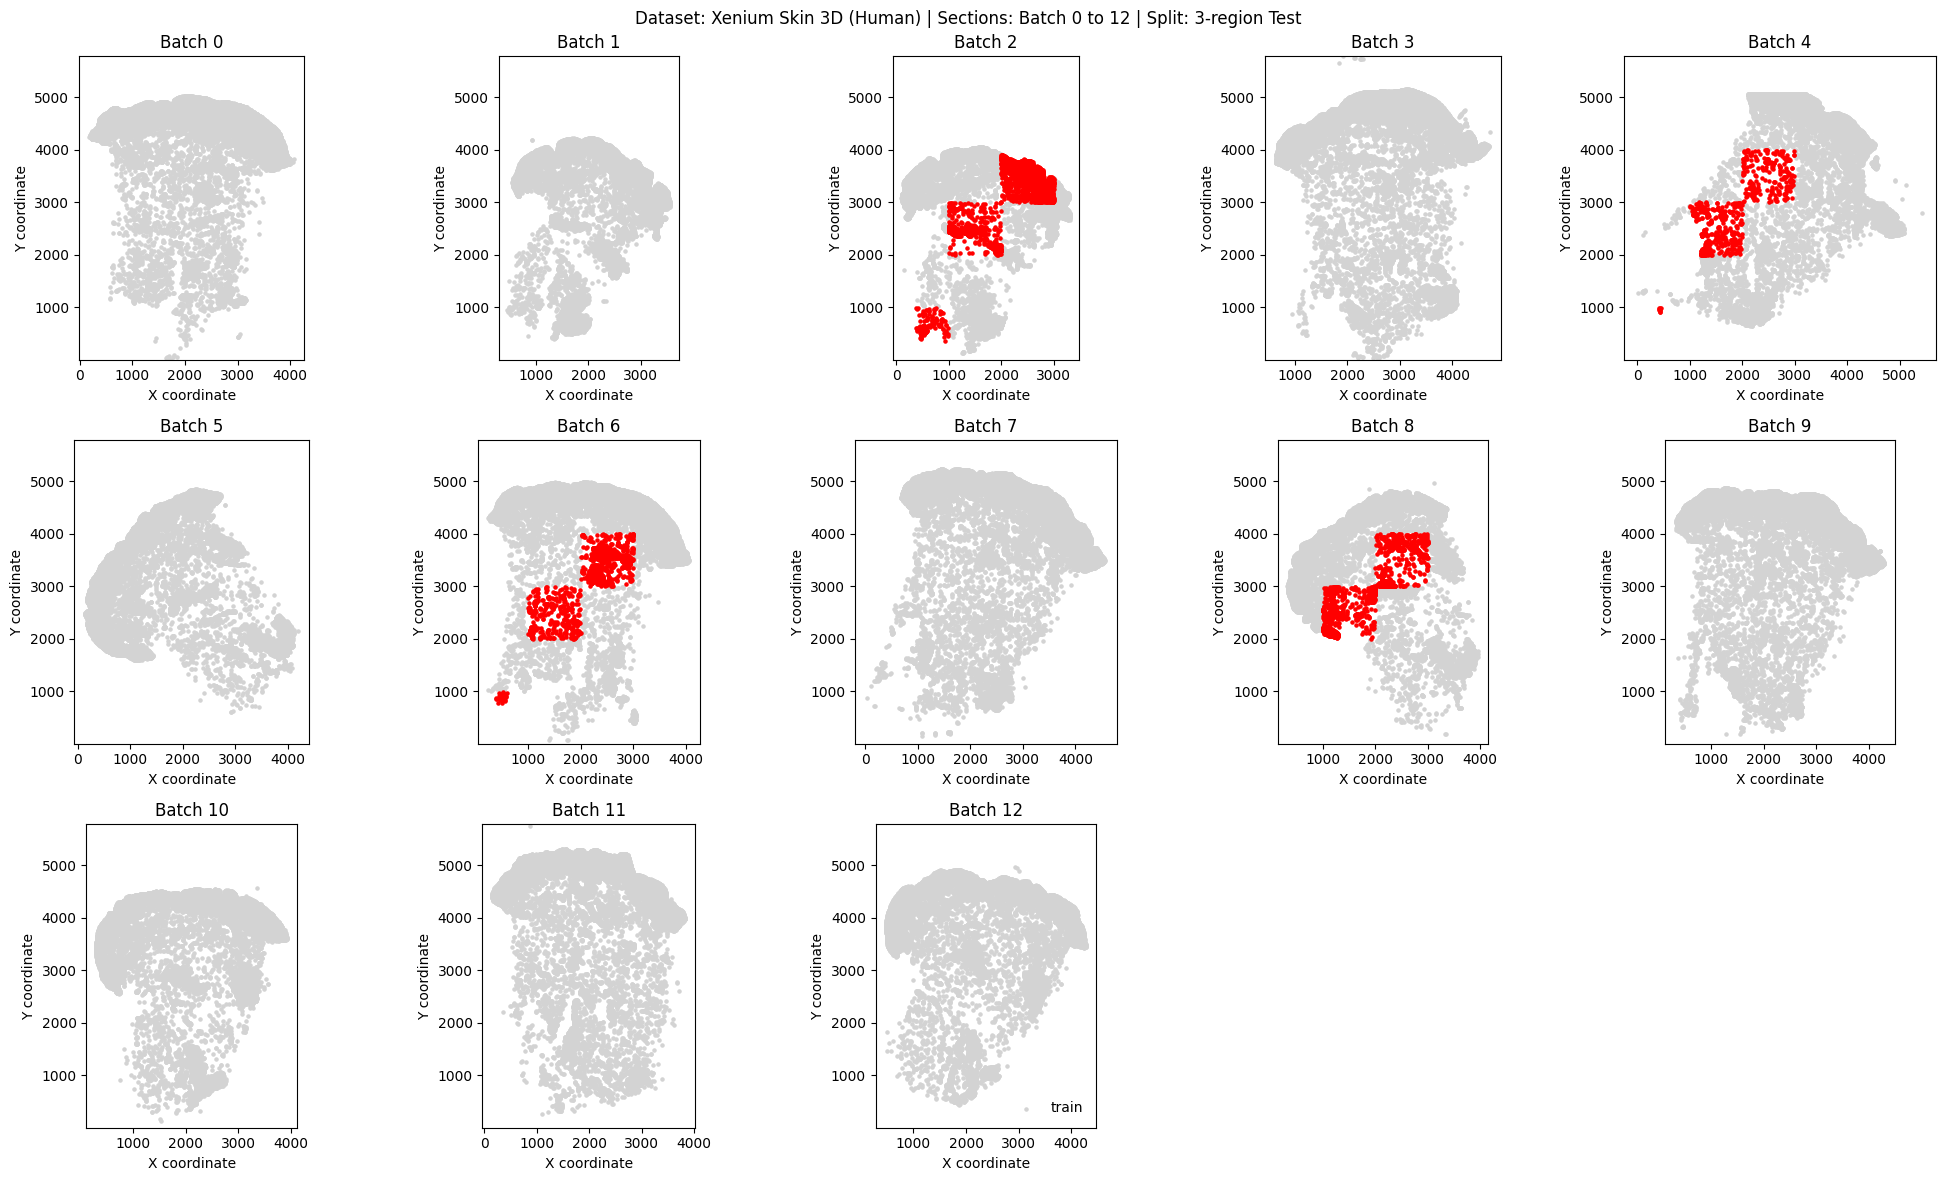

In [12]:
multiple_sections_train_val_test_splits(
    data_batch=xhs1021_15b_1p_3_test_patch_data_batch,
    title='Dataset: Xenium Skin 3D (Human) | Sections: Batch 0 to 12 | Split: 3-region Test',
    height=4,
    width=4,
    xlim=-1
)

## Z-stack View

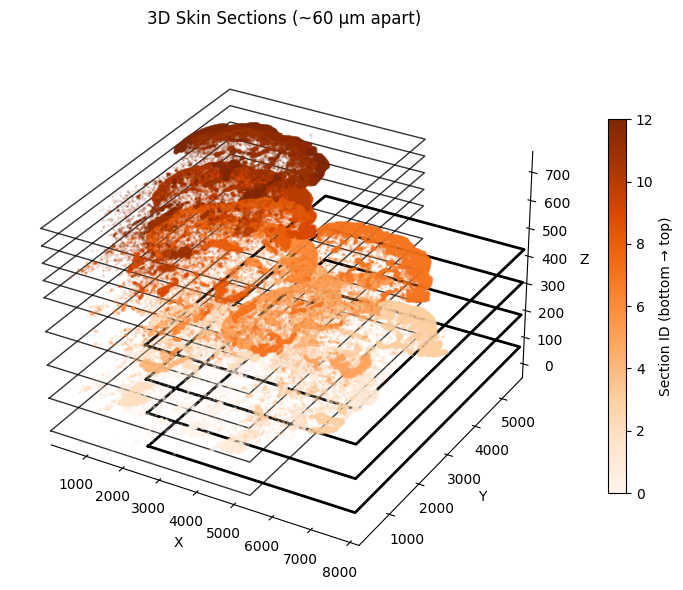

<Figure size 640x480 with 0 Axes>

In [114]:
stack_sections_3d(
    xhs1021_15b_1p_3_test_patch_data_batch,
    spacing_microns=60,
    title="3D Skin Sections (~60 µm apart)",
    alpha=0.1,
    highlight_sections_1based=(2,4,6,8),   # human indexing
    offset_factor=0.005,                        # fraction of global width to shift
    highlight_bbox_lw=2.0,
    normal_bbox_lw=1,
    normal_bbox_alpha=0.8
)
